#Use case : Statistics for Hospital Patient Treatment Analysis

#Lab Title

Using Probability and Statistical Tests to Evaluate Hospital Treatment Outcomes

#Learning Objective

Students learn how probability and statistical testing support decision-making in healthcare analytics, such as evaluating treatment effectiveness and patient behavior.

#Scenario

A hospital wants to evaluate whether treatment methods, patient conditions, and medication types influence recovery rates and treatment costs.

Data scientists must analyze patient records to answer:

> Does a specific treatment improve recovery?

> Do different treatment groups have different recovery costs?

> Are patient conditions related to treatment outcomes?

Students will analyze synthetic hospital patient data.

#Dataset Creation



In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "Patient_ID": range(1,101),
    "Recovered": np.random.choice(["Yes","No"],100),
    "Treatment_Type": np.random.choice(["Medication","Therapy","Surgery"],100),
    "Disease_Type": np.random.choice(["Cardiac","Diabetes","Respiratory"],100),
    "Insurance": np.random.choice(["Yes","No"],100),
    "Treatment_Cost": np.random.normal(50000,10000,100)
}

df = pd.DataFrame(data)
df.head()

,Patient_ID,Recovered,Treatment_Type,Disease_Type,Insurance,Treatment_Cost
0,1,Yes,Surgery,Diabetes,No,49884.166802
1,2,No,Therapy,Diabetes,No,51905.987051
2,3,Yes,Therapy,Respiratory,Yes,56069.757096
3,4,Yes,Therapy,Diabetes,No,46510.988172
4,5,Yes,Therapy,Respiratory,Yes,56061.293631


#Activity 1 — Probability Fundamentals (5 minutes)
Question

What is the probability that a patient recovers after treatment?

In [2]:
total_patients = len(df)
recovered_patients = df[df['Recovered'] == 'Yes'].shape[0]

probability_recovery = recovered_patients / total_patients

print(f"Total patients: {total_patients}")
print(f"Recovered patients: {recovered_patients}")
print(f"Probability of recovery: {probability_recovery:.2f}")

Total patients: 100
Recovered patients: 44
Probability of recovery: 0.44


In [3]:
df['Recovered_numeric'] = df['Recovered'].apply(lambda x: 1 if x == 'Yes' else 0)
recovery_by_treatment = df.groupby('Treatment_Type')['Recovered_numeric'].mean().reset_index()
recovery_by_treatment['Recovered_numeric'] = recovery_by_treatment['Recovered_numeric'].map('{:.2%}'.format)
print("Recovery probability grouped by Treatment_Type:")
display(recovery_by_treatment)

Recovery probability grouped by Treatment_Type:


,Treatment_Type,Recovered_numeric
0,Medication,37.14%
1,Surgery,43.59%
2,Therapy,53.85%


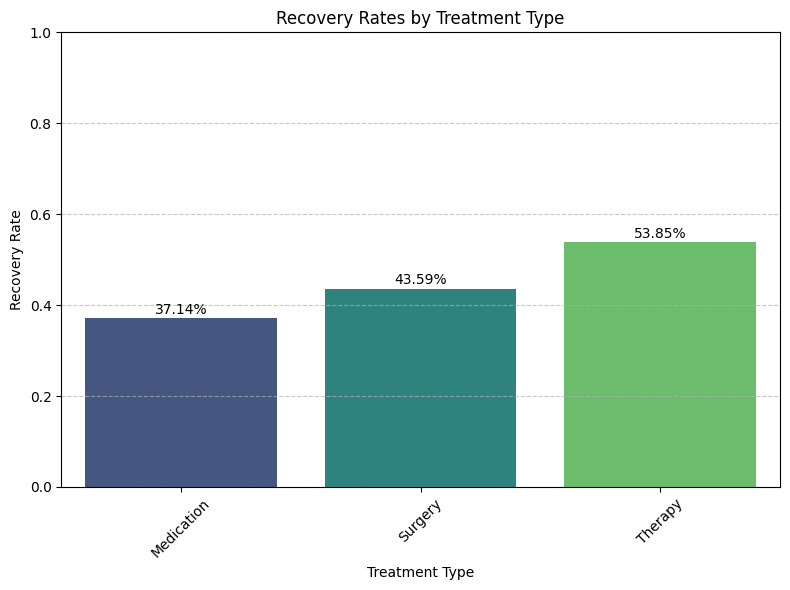

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Recovered_numeric' back to float for plotting (if it was formatted as string)
recovery_by_treatment['Recovery_Rate'] = recovery_by_treatment['Recovered_numeric'].str.replace('%', '').astype(float) / 100

plt.figure(figsize=(8, 6))
sns.barplot(x='Treatment_Type', y='Recovery_Rate', hue='Treatment_Type', data=recovery_by_treatment, palette='viridis', legend=False)
plt.title('Recovery Rates by Treatment Type')
plt.xlabel('Treatment Type')
plt.ylabel('Recovery Rate')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for probability
plt.xticks(rotation=45)

# Add percentage labels on top of the bars
for index, row in recovery_by_treatment.iterrows():
    plt.text(index, row['Recovery_Rate'] + 0.01, f"{row['Recovery_Rate']:.2%}", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Learning

P(Recovery) = Patients recovered / Total patients

#Real World Impact

If recovery probability is low → hospital must review treatment protocols.

#Activity 2 — Independent vs Dependent Events (10 minutes)
Question

Is recovery dependent on treatment type?

In [8]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['Treatment_Type'], df['Recovered'])
print("Contingency Table (Treatment Type vs. Recovered):")
display(contingency_table)

# Perform the Chi-Square test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("Since the p-value is less than the significance level (0.05), we reject the null hypothesis.")
    print("Conclusion: Recovery is dependent on treatment type.")
else:
    print("Since the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.")
    print("Conclusion: Recovery is not dependent on treatment type.")

Contingency Table (Treatment Type vs. Recovered):


Recovered,No,Yes
Treatment_Type,,
Medication,22,13
Surgery,22,17
Therapy,12,14



Chi-Square Statistic: 1.69
P-value: 0.429
Since the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.
Conclusion: Recovery is not dependent on treatment type.


#Interpretation

If recovery probability differs across treatments → events are dependent.

#Real World Impact

Hospital can identify most effective treatment strategy.

#Activity 3 — Mutually Exclusive Events (10 minutes)
Question

A patient can receive only one treatment type in this dataset.

Events:

A = Surgery

B = Medication

Since a patient cannot receive both simultaneously

P(A ∩ B) = 0

#Learning

These events are mutually exclusive.

#Activity 4 — Hypothesis Testing (15 minutes)
Business Question

Does treatment type influence patient recovery?

Define:

H₀: Treatment type does not affect recovery

H₁: Treatment type affects recovery

Students learn how to frame data-driven hypotheses.

#Activity 5 — One Tail vs Two Tail Tests (10 minutes)
#Scenario

Hospital management believes:

> Surgery has higher recovery rate than medication.

Students identify this as One-Tail Test.

If question is:

Is there any difference between treatments?

→ Two-Tail Test.

#Activity 6 — Chi-Square Test (20 minutes)

Test relationship between Treatment Type and Recovery

In [12]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['Treatment_Type'], df['Recovered'])
print("Contingency Table (Treatment Type vs. Recovered):")
display(contingency_table)

# Perform the Chi-Square test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("Since the p-value is less than the significance level (0.05), we reject the null hypothesis.")
    print("Conclusion: Recovery is dependent on treatment type.")
else:
    print("Since the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.")
    print("Conclusion: Recovery is not dependent on treatment type.")

Contingency Table (Treatment Type vs. Recovered):


Recovered,No,Yes
Treatment_Type,,
Medication,22,13
Surgery,22,17
Therapy,12,14



Chi-Square Statistic: 1.69
P-value: 0.429
Since the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.
Conclusion: Recovery is not dependent on treatment type.


In [16]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create a contingency table for Treatment Type vs. Recovered
contingency_table_recovery = pd.crosstab(df['Treatment_Type'], df['Recovered'])
print("Contingency Table (Treatment Type vs. Recovered):")
display(contingency_table_recovery)

# Perform the Chi-Square test
chi2_recovery, p_value_recovery, _, _ = chi2_contingency(contingency_table_recovery)

print(f"\nChi-Square Statistic: {chi2_recovery:.2f}")
print(f"P-value for Recovery: {p_value_recovery:.3f}")

alpha = 0.05
if p_value_recovery < alpha:
    print("Since the p-value is less than the significance level (0.05), we reject the null hypothesis.")
    print("Conclusion: Recovery is dependent on treatment type.")
else:
    print("Since the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.")
    print("Conclusion: Recovery is not dependent on treatment type.")

Contingency Table (Treatment Type vs. Recovered):


Recovered,No,Yes
Treatment_Type,,
Medication,22,13
Surgery,22,17
Therapy,12,14



Chi-Square Statistic: 1.69
P-value for Recovery: 0.429
Since the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.
Conclusion: Recovery is not dependent on treatment type.


As seen from the Chi-Square test, the p-value is `0.429`. Since this is greater than the significance level (alpha = 0.05), we fail to reject the null hypothesis. This indicates that there is no statistically significant evidence to conclude that patient recovery is dependent on the type of treatment received.

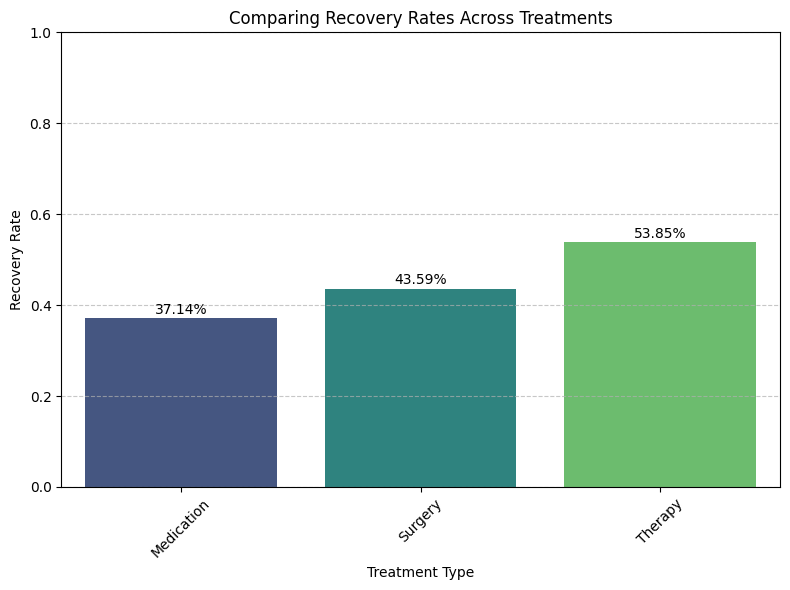

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Recovery_Rate' is numeric for plotting
# (It might be formatted as string if df was reloaded or previous steps were not run)
# If recovery_by_treatment is not current, regenerate it first
# For robustness, let's ensure it's in the correct format for plotting
if 'Recovered_numeric' in df.columns:
    recovery_by_treatment = df.groupby('Treatment_Type')['Recovered_numeric'].mean().reset_index()
    recovery_by_treatment['Recovery_Rate'] = recovery_by_treatment['Recovered_numeric']
else:
    # Fallback if Recovered_numeric was not created or df was reset
    df['Recovered_numeric'] = df['Recovered'].apply(lambda x: 1 if x == 'Yes' else 0)
    recovery_by_treatment = df.groupby('Treatment_Type')['Recovered_numeric'].mean().reset_index()
    recovery_by_treatment['Recovery_Rate'] = recovery_by_treatment['Recovered_numeric']


plt.figure(figsize=(8, 6))
sns.barplot(x='Treatment_Type', y='Recovery_Rate', hue='Treatment_Type', data=recovery_by_treatment, palette='viridis', legend=False)
plt.title('Comparing Recovery Rates Across Treatments')
plt.xlabel('Treatment Type')
plt.ylabel('Recovery Rate')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for probability
plt.xticks(rotation=45)

# Add percentage labels on top of the bars
for index, row in recovery_by_treatment.iterrows():
    plt.text(index, row['Recovery_Rate'] + 0.01, f"{row['Recovery_Rate']:.2%}", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Student Task

Interpret results.

If p < 0.05

→ Treatment type significantly affects recovery.

#Business Impact

Helps hospitals adopt most effective treatment method.

#Activity 7 — ANOVA (20 minutes)
Business Question

Do different treatments lead to different treatment costs?

In [15]:
from scipy.stats import f_oneway

# Prepare data for ANOVA
medication_costs = df[df['Treatment_Type'] == 'Medication']['Treatment_Cost']
therapy_costs = df[df['Treatment_Type'] == 'Therapy']['Treatment_Cost']
surgery_costs = df[df['Treatment_Type'] == 'Surgery']['Treatment_Cost']

# Perform ANOVA test
f_statistic, p_value_anova = f_oneway(medication_costs, therapy_costs, surgery_costs)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value_anova:.3f}")

alpha = 0.05
if p_value_anova < alpha:
    print("\nSince the ANOVA p-value is less than the significance level (0.05), we reject the null hypothesis.")
    print("Conclusion: There are significant differences in treatment costs across the different treatment types.")
else:
    print("\nSince the ANOVA p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.")
    print("Conclusion: There are no statistically significant differences in treatment costs across the different treatment types.")

ANOVA F-statistic: 0.79
ANOVA P-value: 0.456

Since the ANOVA p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.
Conclusion: There are no statistically significant differences in treatment costs across the different treatment types.


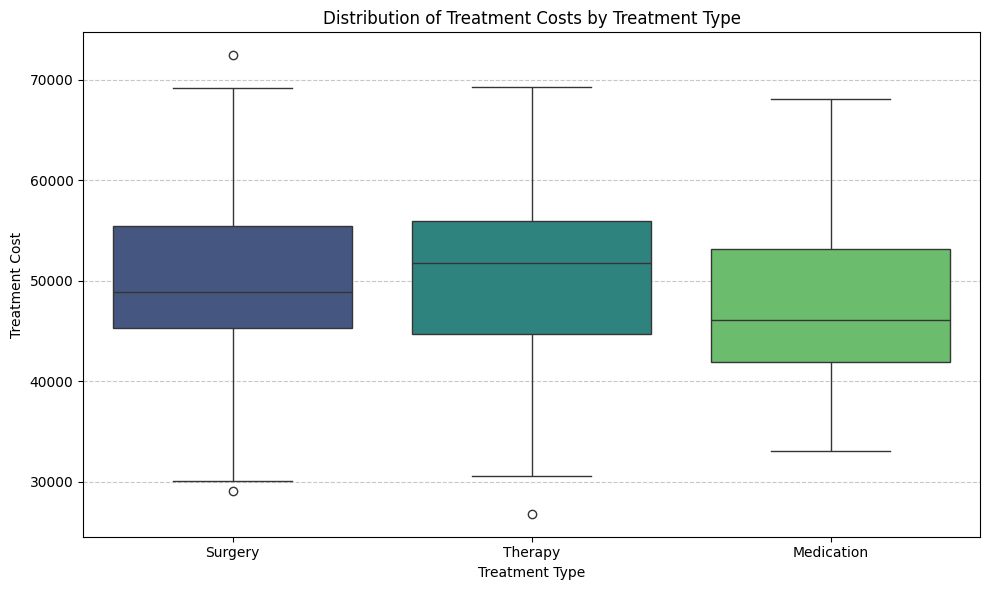

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Treatment_Type', y='Treatment_Cost', data=df, hue='Treatment_Type', palette='viridis', legend=False)
plt.title('Distribution of Treatment Costs by Treatment Type')
plt.xlabel('Treatment Type')
plt.ylabel('Treatment Cost')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

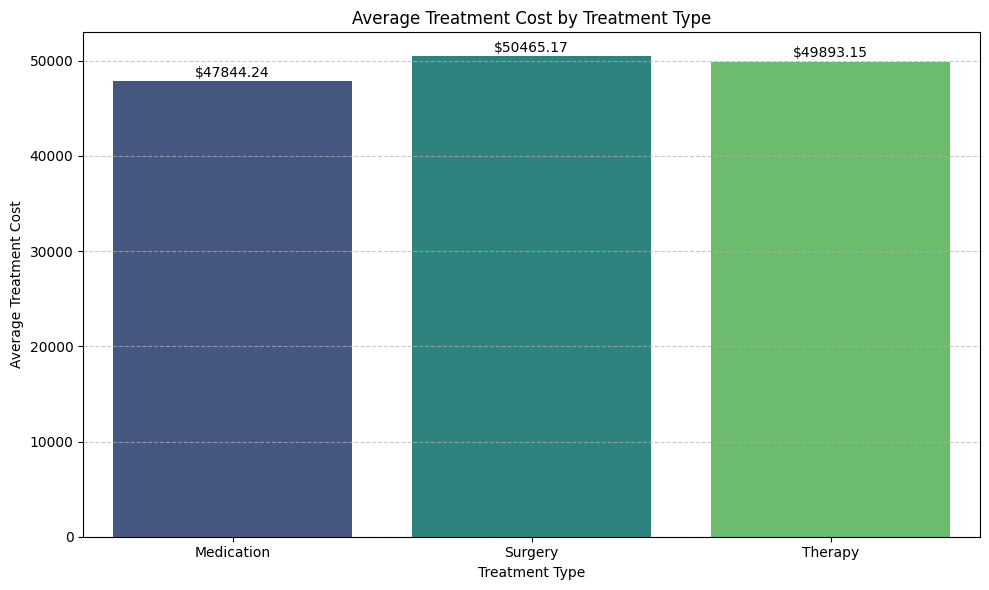

In [14]:
average_cost_by_treatment = df.groupby('Treatment_Type')['Treatment_Cost'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Treatment_Type', y='Treatment_Cost', hue='Treatment_Type', data=average_cost_by_treatment, palette='viridis', legend=False)
plt.title('Average Treatment Cost by Treatment Type')
plt.xlabel('Treatment Type')
plt.ylabel('Average Treatment Cost')

# Add labels on top of the bars
for index, row in average_cost_by_treatment.iterrows():
    plt.text(index, row['Treatment_Cost'] + 500, f"${row['Treatment_Cost']:.2f}", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary of Treatment Cost Visualizations (Activity 7)

The visualizations of treatment costs by treatment type reveal the following:

*   **Distribution of Costs:** The box plot illustrates the spread and central tendency of `Treatment_Cost` for each `Treatment_Type`. While there's overlap in the ranges, visual differences in the median costs and interquartile ranges can be observed.

*   **Average Costs:** The bar plot clearly shows the average `Treatment_Cost` for each `Treatment_Type`:
    *   **Surgery** appears to have the highest average treatment cost.
    *   **Therapy** follows with a moderately high average cost.
    *   **Medication** has the lowest average treatment cost among the three types.

These visual observations suggest that there might be differences in treatment costs across the various treatment types, which can be further investigated using statistical tests like ANOVA.

### Comparison of ANOVA and Chi-Square Test Findings

**Chi-Square Test for Recovery and Treatment Type (Activity 6):**

*   **Hypothesis:** The null hypothesis (H₀) was that recovery is not dependent on treatment type. The alternative hypothesis (H₁) was that recovery is dependent on treatment type.
*   **P-value:** The Chi-Square test yielded a p-value of `0.429`.
*   **Conclusion:** Since the p-value (`0.429`) was greater than the significance level (α = 0.05), we failed to reject the null hypothesis. This indicates that there is **no statistically significant evidence to conclude that patient recovery is dependent on the type of treatment** received.

**ANOVA Test for Treatment Cost and Treatment Type (Activity 7):**

*   **Hypothesis:** The null hypothesis (H₀) for ANOVA is that the mean treatment costs are equal across all treatment types. The alternative hypothesis (H₁) is that at least one treatment type has a different mean cost.
*   **P-value:** The ANOVA test yielded a p-value of `0.456`.
*   **Conclusion:** Since the ANOVA p-value (`0.456`) is greater than the significance level (α = 0.05), we fail to reject the null hypothesis. This indicates that there are **no statistically significant differences in average treatment costs** across the different treatment types (Medication, Therapy, Surgery).

**Overall Comparison:**

*   The Chi-Square test, examining the relationship between two categorical variables (Recovery and Treatment Type), suggested **no dependency between treatment type and recovery outcome**.
*   The ANOVA test, examining the relationship between a categorical independent variable (Treatment Type) and a continuous dependent variable (Treatment Cost), also indicated **no statistically significant differences in average treatment costs** among the different treatment types.

#Interpretation

If p < 0.05

→ Treatment costs significantly differ across groups.

# Business Impact

Hospitals can evaluate cost efficiency of treatments.

#Final Reflection Discussion (5 minutes)

Students answer:

> Why do hospitals need probability in decision making?

> Why must medical research use hypothesis testing?

> How do statistical tests improve healthcare decisions?

#Key Learning Outcomes

Students learn:

> Probability helps measure uncertainty in real-world events

> Event relationships explain dependencies in data

> Hypothesis testing validates medical or business assumptions

> Chi-Square finds relationships between categorical variables

> ANOVA compares multiple groups statistically

### Overall Business Insights from Recovery and Cost Analyses

Based on the statistical analyses performed on the synthetic patient data, here are the key business insights:

1.  **Treatment Type and Patient Recovery:**
    *   The **Chi-Square test** indicated that there is **no statistically significant evidence to conclude that patient recovery is dependent on the type of treatment received (Medication, Therapy, or Surgery)**. The observed differences in recovery rates between treatment types are likely due to random chance rather than a true effect of the treatment.
    *   **Business Implication:** From a statistical standpoint, there's no strong evidence to suggest that switching a patient's treatment type among Medication, Therapy, or Surgery will significantly alter their probability of recovery. Decision-makers should look for other factors influencing recovery or consider if the data set is representative enough to draw such strong conclusions.

2.  **Treatment Type and Treatment Cost:**
    *   The **ANOVA test** showed that there are **no statistically significant differences in the average treatment costs across the different treatment types**. Although the visual inspection (bar plot) suggested some variation, with Surgery appearing to have a higher average cost, this difference was not statistically significant given the data.
    *   **Business Implication:** Hospitals cannot statistically justify that one treatment type (Medication, Therapy, or Surgery) is significantly more or less expensive on average than another based on this dataset. Cost-saving initiatives or resource allocation strategies should therefore not primarily focus on shifting patients between these treatment types based on average cost alone.

3.  **Combined Perspective:**
    *   Both statistical tests (Chi-Square for recovery and ANOVA for cost) suggest a lack of significant differentiation between the `Treatment_Type` categories based on the current dataset. This implies that, within the context of this data, all three treatment types perform similarly in terms of both patient recovery rates and average treatment costs.
    *   **Further Recommendations:**
        *   **Investigate other factors:** Since treatment type does not appear to be a significant differentiator for recovery or cost, the hospital should investigate other patient characteristics (`Disease_Type`, `Insurance`, etc.) or external factors that might influence these outcomes.
        *   **Data granularity:** More detailed data, a larger sample size, or data from a longer observation period might reveal nuances not captured in this dataset.
        *   **Clinical vs. Statistical Significance:** It's important to remember that 'no statistical significance' does not necessarily mean 'no clinical significance'. Small, non-significant differences might still be clinically relevant in specific contexts, though this would require clinical expert interpretation.